In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay, roc_curve
)
import joblib

In [3]:
df = pd.read_csv("heart.csv")

print("\nDataset Preview:\n", df.head())
print("\nShape:", df.shape)



Dataset Preview:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Shape: (1025, 14)


In [4]:
likely_categorical = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
target_col = "target"

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

categorical_features = [c for c in likely_categorical if c in X.columns]
numeric_features = [c for c in X.columns if c not in categorical_features]

print("\nCategorical features:", categorical_features)
print("Numeric features:", numeric_features)


Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


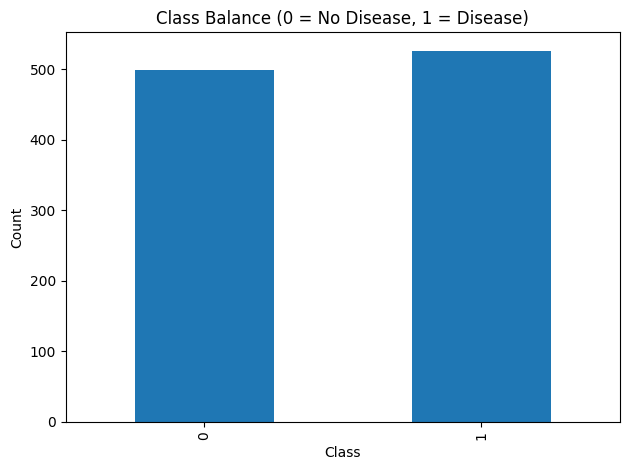

In [5]:
class_counts = y.value_counts().sort_index()
plt.figure()
class_counts.plot(kind="bar")
plt.title("Class Balance (0 = No Disease, 1 = Disease)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("class_balance.png")
plt.show()


In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

In [7]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])


In [8]:
logreg = LogisticRegression(max_iter=1000, solver="lbfgs")

clf = Pipeline([
    ("prep", preprocess),
    ("model", logreg)
])


In [9]:
clf.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [10]:
val_proba = clf.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, val_proba)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_thresh = thresholds[best_idx]

def metrics(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score)
    }

val_pred_default = (val_proba >= 0.5).astype(int)
val_pred_best = (val_proba >= best_thresh).astype(int)

print("\nValidation Metrics (threshold=0.5):", metrics(y_val, val_pred_default, val_proba))
print("\nBest threshold from Youden's J:", best_thresh)
print("\nValidation Metrics (best threshold):", metrics(y_val, val_pred_best, val_proba))



Validation Metrics (threshold=0.5): {'accuracy': 0.8246753246753247, 'precision': 0.8170731707317073, 'recall': 0.8481012658227848, 'f1': 0.8322981366459627, 'roc_auc': np.float64(0.9277637130801688)}

Best threshold from Youden's J: 0.4305858122478544

Validation Metrics (best threshold): {'accuracy': 0.8636363636363636, 'precision': 0.8295454545454546, 'recall': 0.9240506329113924, 'f1': 0.874251497005988, 'roc_auc': np.float64(0.9277637130801688)}


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(clf, X_train, y_train, scoring="roc_auc", cv=cv)
print("\nCV ROC-AUC (mean ± std):", cv_auc.mean(), cv_auc.std())


CV ROC-AUC (mean ± std): 0.9291180630132387 0.02410266109790905


In [12]:
test_proba = clf.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_thresh).astype(int)

print("\nTest Metrics:", metrics(y_test, test_pred, test_proba))



val_results = metrics(y_val, val_pred_best, val_proba)
test_results = metrics(y_test, test_pred, test_proba)

print("\n============================")
print("MODEL ACCURACY (PERCENT)")
print("============================")

print("Validation Accuracy : {:.2f}%".format(val_results["accuracy"] * 100))
print("Validation Precision: {:.2f}%".format(val_results["precision"] * 100))
print("Validation Recall   : {:.2f}%".format(val_results["recall"] * 100))
print("Validation F1 Score : {:.2f}%".format(val_results["f1"] * 100))

print("\nTest Accuracy       : {:.2f}%".format(test_results["accuracy"] * 100))
print("Test Precision      : {:.2f}%".format(test_results["precision"] * 100))
print("Test Recall         : {:.2f}%".format(test_results["recall"] * 100))
print("Test F1 Score       : {:.2f}%".format(test_results["f1"] * 100))
print("Test ROC-AUC        : {:.2f}%".format(test_results["roc_auc"] * 100))


Test Metrics: {'accuracy': 0.8961038961038961, 'precision': 0.8620689655172413, 'recall': 0.9493670886075949, 'f1': 0.9036144578313253, 'roc_auc': np.float64(0.9633755274261604)}

MODEL ACCURACY (PERCENT)
Validation Accuracy : 86.36%
Validation Precision: 82.95%
Validation Recall   : 92.41%
Validation F1 Score : 87.43%

Test Accuracy       : 89.61%
Test Precision      : 86.21%
Test Recall         : 94.94%
Test F1 Score       : 90.36%
Test ROC-AUC        : 96.34%


<Figure size 640x480 with 0 Axes>

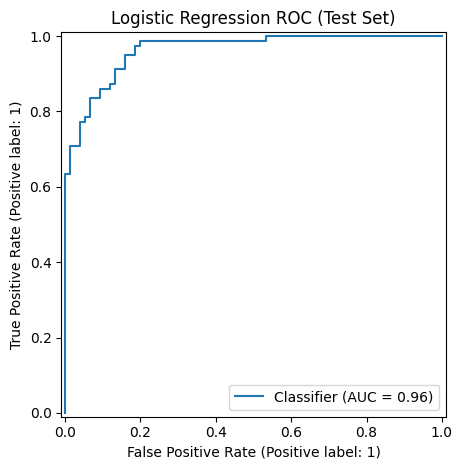

In [13]:
plt.figure()
RocCurveDisplay.from_predictions(y_test, test_proba)
plt.title("Logistic Regression ROC (Test Set)")
plt.tight_layout()
plt.savefig("roc_curve_test.png")
plt.show()

<Figure size 640x480 with 0 Axes>

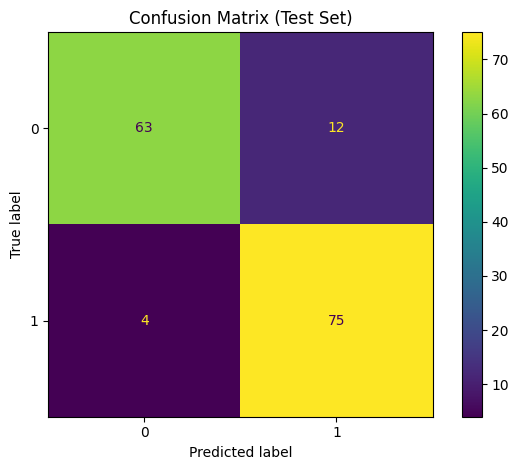

In [14]:
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, test_pred)
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix_test.png")
plt.show()


In [15]:
ohe = clf.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
cat_names = ohe.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)

coefs = clf.named_steps["model"].coef_.ravel()
odds_ratios = np.exp(coefs)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "odds_ratio": odds_ratios
}).sort_values("odds_ratio", ascending=False)

print("\nTop Feature Odds Ratios:\n", coef_df.head())



Top Feature Odds Ratios:
    feature      coef  odds_ratio
25    ca_4  1.423276    4.150697
21    ca_0  1.279063    3.593270
10    cp_3  0.861153    2.365886
5    sex_0  0.847413    2.333602
9     cp_2  0.635665    1.888277


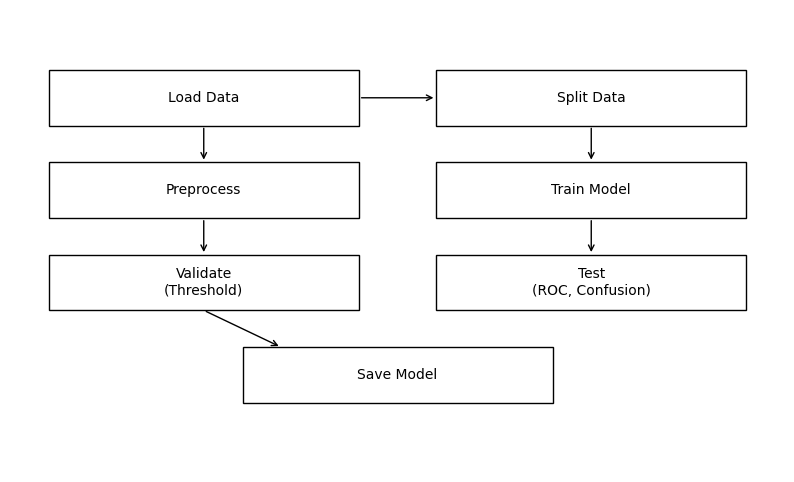

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

def box(x, y, text):
    rect = plt.Rectangle((x, y), 0.4, 0.12, fill=False)
    ax.add_patch(rect)
    ax.text(x+0.2, y+0.06, text, ha="center", va="center")

def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->"))

box(0.05, 0.75, "Load Data")
box(0.55, 0.75, "Split Data")
arrow(0.45, 0.81, 0.55, 0.81)

box(0.05, 0.55, "Preprocess")
arrow(0.25, 0.75, 0.25, 0.67)

box(0.55, 0.55, "Train Model")
arrow(0.75, 0.75, 0.75, 0.67)

box(0.05, 0.35, "Validate\n(Threshold)")
arrow(0.25, 0.55, 0.25, 0.47)

box(0.55, 0.35, "Test\n(ROC, Confusion)")
arrow(0.75, 0.55, 0.75, 0.47)

box(0.30, 0.15, "Save Model")
arrow(0.25, 0.35, 0.35, 0.27)

plt.savefig("ml_pipeline_flowchart.png")
plt.show()

In [ ]:
Path("artifacts").mkdir(exist_ok=True)
joblib.dump(clf, "artifacts/heart_logreg_pipeline.joblib")
coef_df.to_csv("artifacts/odds_ratios.csv", index=False)

print("\nModel saved successfully!")


Model saved successfully!


In [17]:
print("\n============================")
print(" FINAL IMPLEMENTATION TEST ")
print("============================")

# Example new patient data (you can change the values)
new_patient = pd.DataFrame({
    'age': [54],
    'sex': [1],
    'cp': [2],
    'trestbps': [130],
    'chol': [250],
    'fbs': [0],
    'restecg': [0],
    'thalach': [160],
    'exang': [0],
    'oldpeak': [1.2],
    'slope': [1],
    'ca': [0],
    'thal': [2]
})


 FINAL IMPLEMENTATION TEST 


In [18]:
prob = clf.predict_proba(new_patient)[:, 1][0]
pred = clf.predict(new_patient)[0]

print(f"\nPredicted Probability of Heart Disease: {prob*100:.2f}%")
print("Prediction:", " Heart Disease" if pred == 1 else " No Heart Disease")


Predicted Probability of Heart Disease: 83.59%
Prediction:  Heart Disease


In [26]:

df.to_csv("heart.csv", index=False)
plt.savefig("class_balance.png")
plt.savefig("confusion_matrix_test.png")
plt.savefig("ml_pipeline_flowchart.png")
plt.savefig("roc_curve_test.png")


<Figure size 640x480 with 0 Axes>

In [27]:
!ls


class_balance.png	   heart.csv		      roc_curve_test.png
confusion_matrix_test.png  ml_pipeline_flowchart.png  sample_data
